### 4. Dataset de Consumo de Energía Doméstica
##### Url del dataset: 
- **https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption**

In [1]:
import os
import sys

carpeta_actual = os.getcwd()
ruta_raiz = os.path.dirname(carpeta_actual)
print(ruta_raiz)
# Añade la raíz al buscador de Python si no está ahí
if ruta_raiz not in sys.path:
    sys.path.append(ruta_raiz)

# Ahora ya puedes importar tus funciones
from utilidades.mis_funciones import *

c:\Users\mbang\Desktop\GitMikis\Proyecto2


In [5]:
# Cargar el archivo
ruta_archivo = f"{ruta_raiz}/datasets/household_power_consumption.txt"
df4 = cargar_archivo_drive(ruta_archivo,";")
analisis_inicial(df4)

c:\Users\mbang\Desktop\GitMikis\Proyecto2\utilidades\mis_funciones.py:13: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(ruta_archivo,sep=separador)


Tamaño: (2075259, 9)

Primeras 5 filas del DataFrame:
         Date      Time Global_active_power Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00               4.216                 0.418  234.840   
1  16/12/2006  17:25:00               5.360                 0.436  233.630   
2  16/12/2006  17:26:00               5.374                 0.498  233.290   
3  16/12/2006  17:27:00               5.388                 0.502  233.740   
4  16/12/2006  17:28:00               3.666                 0.528  235.680   

  Global_intensity Sub_metering_1 Sub_metering_2  Sub_metering_3  
0           18.400          0.000          1.000            17.0  
1           23.000          0.000          1.000            16.0  
2           23.000          0.000          2.000            17.0  
3           23.000          0.000          1.000            17.0  
4           15.800          0.000          1.000            17.0  
Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
Ra

### El ejecutar la función analisis_inicial me avisó que hay varias columnas numéricas que están como object. Esto es porque probablemente tienen valores que no son números. También tenemos nulos en Sub_metering_3.

* Primero, voy a asegurarme de que todas las columnas que deben ser numéricas, lo sean. Además juntaré las columnas Date y Time, creo que es más útil así.

In [14]:
# Lo infaltable
df4_clean = df4.copy()
df4_clean.shape

(2075259, 9)

In [15]:
# Combinar Date y Time en una columna de tipo datetime
df4_clean['DateTime'] = pd.to_datetime(df4_clean['Date'] + ' ' + df4_clean['Time'], dayfirst=True)

# Eliminar las columnas originales 'Date' y 'Time', salen 2 entra 1
df4_clean = df4_clean.drop(columns=['Date', 'Time'])

# Convertir las columnas numéricas que están como 'object' a float
object_numeric_cols = ['Global_active_power','Global_reactive_power','Voltage','Global_intensity','Sub_metering_1','Sub_metering_2']
for col in object_numeric_cols: df4_clean[col] = pd.to_numeric(df4_clean[col], errors='coerce')

display(df4_clean.info())
display(df4_clean.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Global_active_power    float64       
 1   Global_reactive_power  float64       
 2   Voltage                float64       
 3   Global_intensity       float64       
 4   Sub_metering_1         float64       
 5   Sub_metering_2         float64       
 6   Sub_metering_3         float64       
 7   DateTime               datetime64[ns]
dtypes: datetime64[ns](1), float64(7)
memory usage: 126.7 MB


None

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,DateTime
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


In [16]:
# Voy a ver si quedaron nulos después del cambio
contar_nulos(df4_clean)

                       Total Nulos  Porcentaje (%)
Global_active_power          25979        1.251844
Global_reactive_power        25979        1.251844
Voltage                      25979        1.251844
Global_intensity             25979        1.251844
Sub_metering_1               25979        1.251844
Sub_metering_2               25979        1.251844
Sub_metering_3               25979        1.251844
DateTime                         0        0.000000


In [17]:
# Verificar las filas que tienen nulos, tengo una leve sospecha...
filas_con_nulos = df4_clean[df4_clean.isnull().any(axis=1)]
# Mostrar las filas que tienen nulos
display(filas_con_nulos)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,DateTime
6839,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006-12-21 11:23:00
6840,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006-12-21 11:24:00
19724,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006-12-30 10:08:00
19725,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006-12-30 10:09:00
41832,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2007-01-14 18:36:00
...,...,...,...,...,...,...,...,...
1990185,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-09-28 19:09:00
1990186,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-09-28 19:10:00
1990187,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-09-28 19:11:00
1990188,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-09-28 19:12:00


### Tratamiento de valores nulos
Gracias al cambio de dato de las columnas se observa que existen 25979 filas nulas, digo filas porque veo que sólo se encuentra la fecha con datos en esas filas, el resto de columnas está en nulos. Qué fácil sería llegar y eliminar esas filas, pero me encuentro ante una dataset de series de tiempo, lo que implica que si borro esas filas se perderían minutos, horas o días en los que no se tomaron muestras (Aunque creo que eso sucedió). A mí parecer la continuidad temporal es crucial, no deseo crear brechas de tiempo porque eso dificultaría el análisis. Por lo que intentaré crear una imputación basándome en la interpolación lineal, pues el consumo eléctrico, que es un fenómeno físico, tiende a variar de forma relativamente suave, es decir, no hay saltos de 0 a máximos o viceversa en un minuto (a no ser que estén creando un Frankestein). Así, al rellenar los nulos en vez de eliminarlos, mantengo todas las fechas del dataset.

In [18]:
# Antes de imputar, voy a ordenar por tiempo para que la interpolación tenga sentido
df4_clean = df4_clean.sort_values(by='DateTime')

print("Cantidad de nulos antes de la imputación:")
print(df4_clean.isnull().sum())

# Imputar valores nulos usando interpolación lineal
# Me aseguro que el índice sea el DateTime para una interpolación temporal efectiva
df4_clean_imputado = df4_clean.set_index('DateTime').interpolate(method='time').reset_index()

print("\nCantidad de nulos después de la imputación:")
print(df4_clean_imputado.isnull().sum())

display(df4_clean_imputado.head())

Cantidad de nulos antes de la imputación:
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
DateTime                     0
dtype: int64

Cantidad de nulos después de la imputación:
DateTime                 0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


,DateTime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


### Distribución de Variables Numéricas

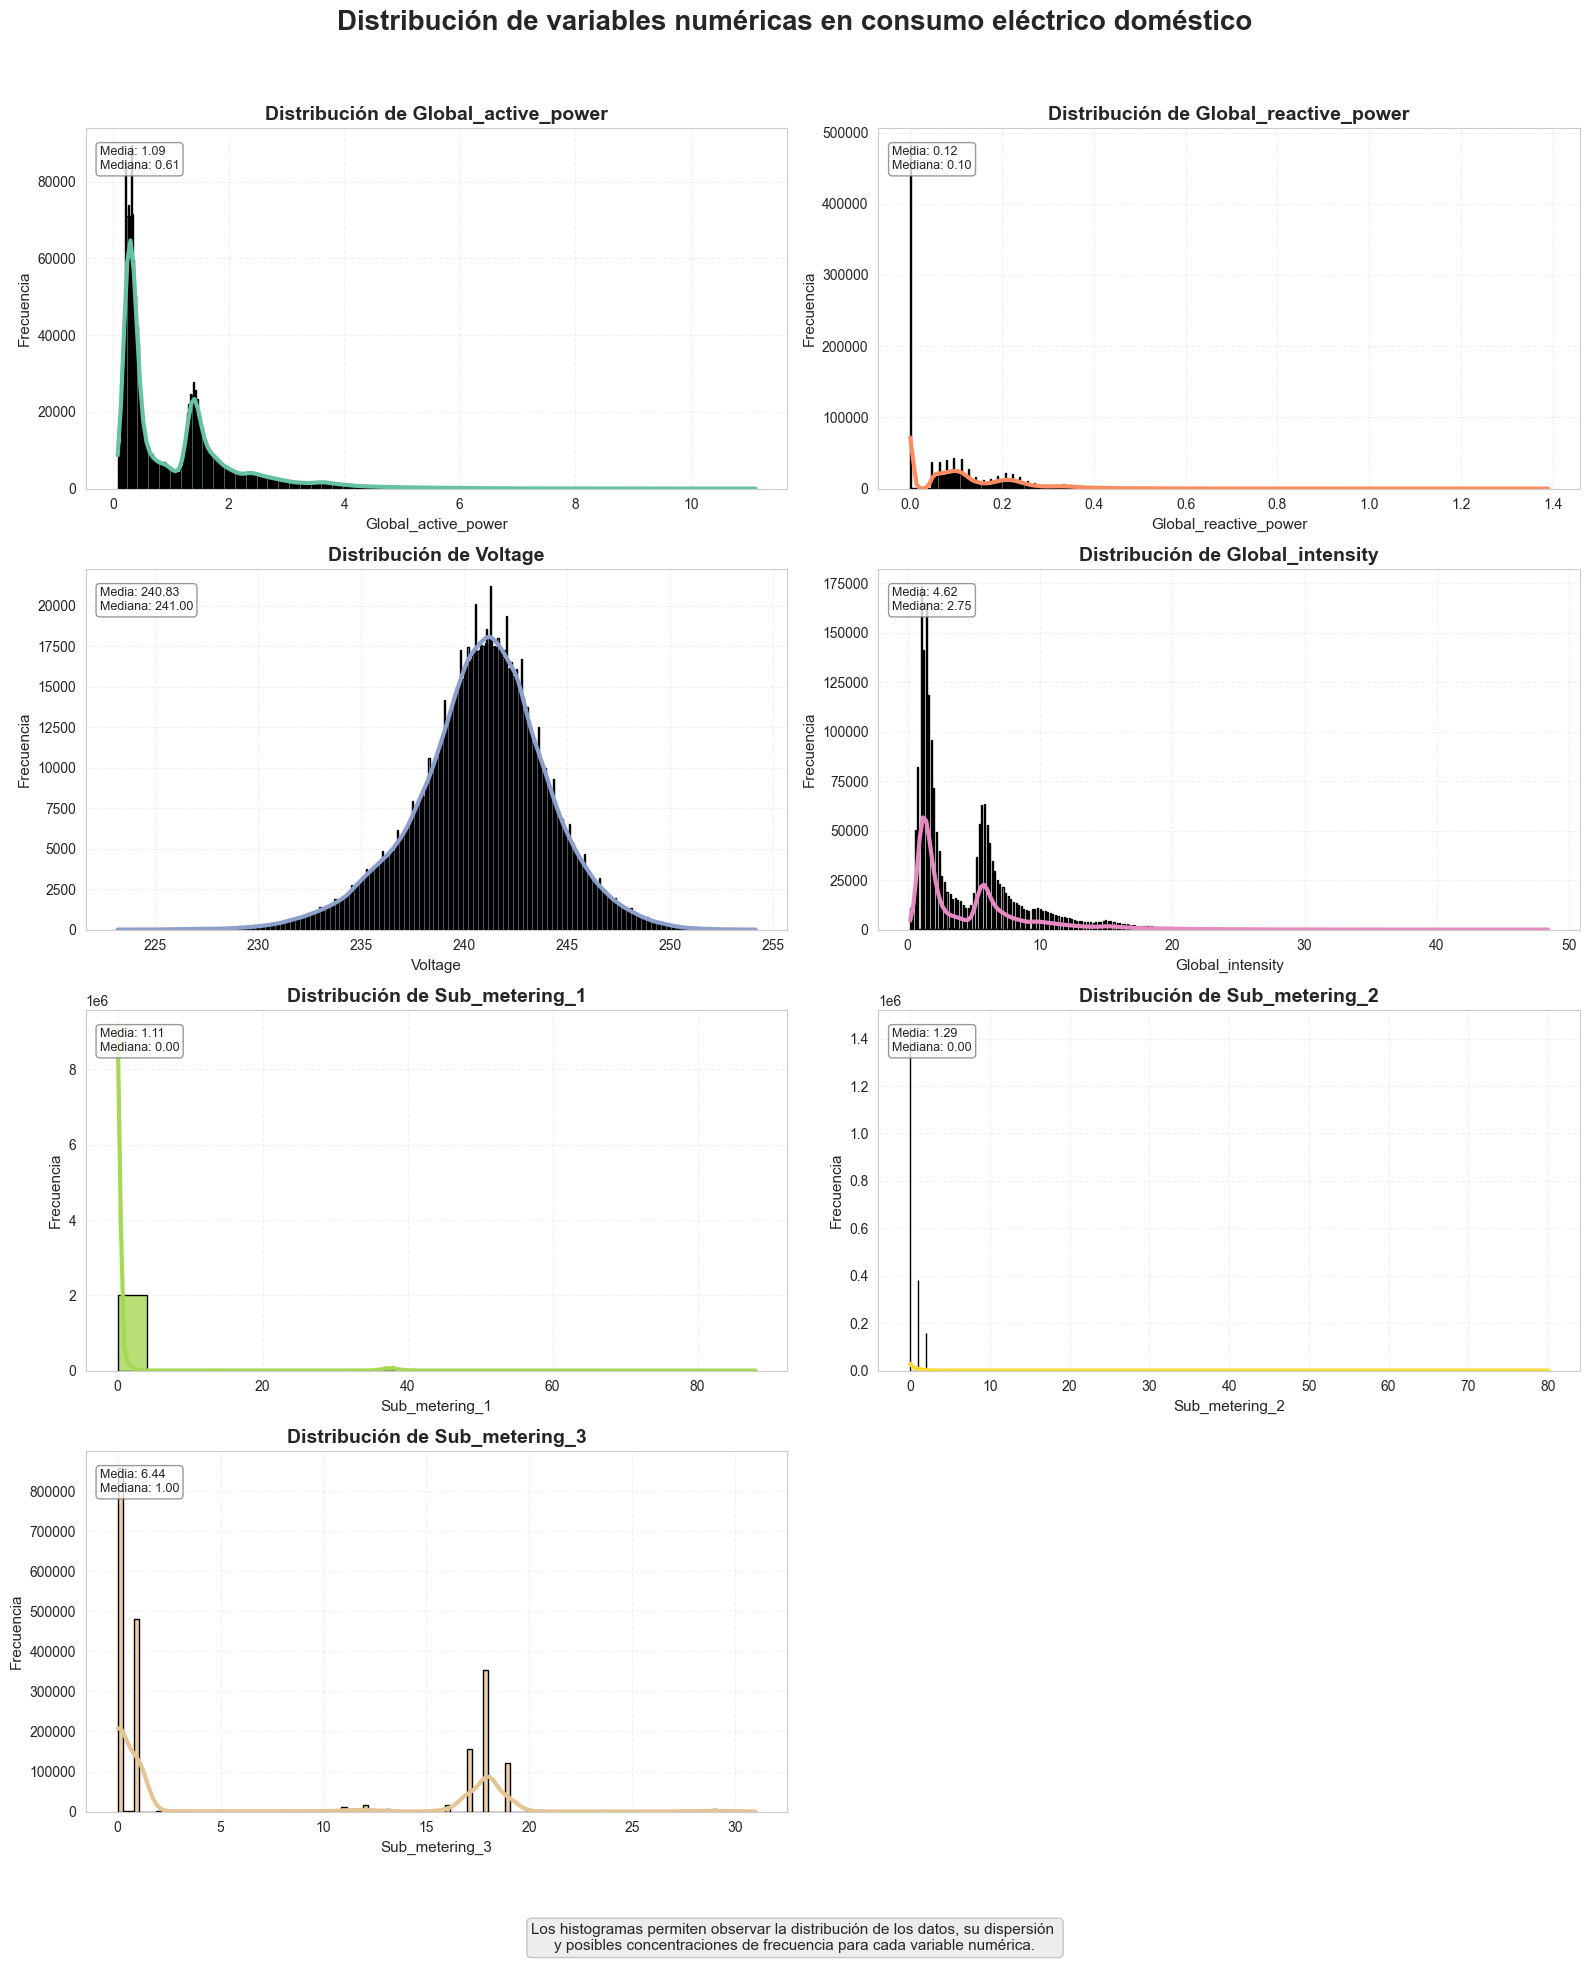

In [19]:
# Voy a seleccionar todas las columnas numéricas (excluyendo 'DateTime')
num_cols_df4 = df4_clean_imputado.select_dtypes(include=[np.number]).columns

# Usar la función graficar_histogramas
graficar_histogramas(df4_clean_imputado, titulo='Distribución de variables numéricas en consumo eléctrico doméstico')

### Identificación y Visualización de Outliers

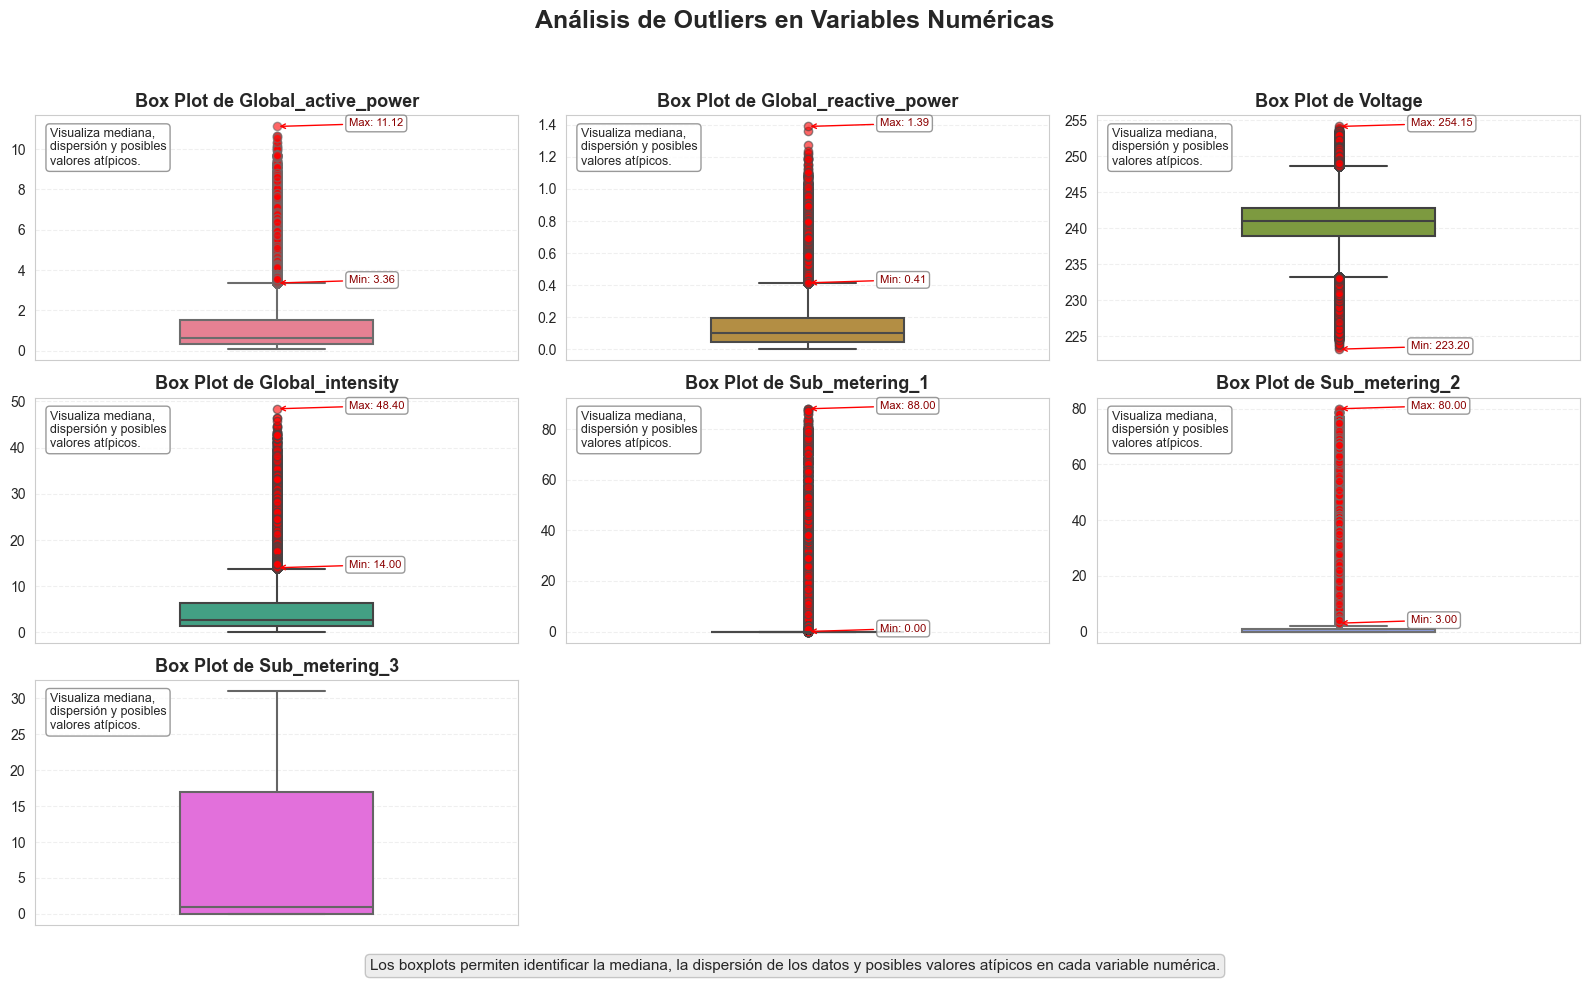

In [20]:
# Identificar columnas numéricas para el análisis de outliers
col_num_df4 = df4_clean_imputado.select_dtypes(include=[np.number]).columns.tolist()
# Usar la función boxplots para visualizar los outliers
boxplots(df4_clean_imputado, col_num_df4)

### Matriz de Correlación

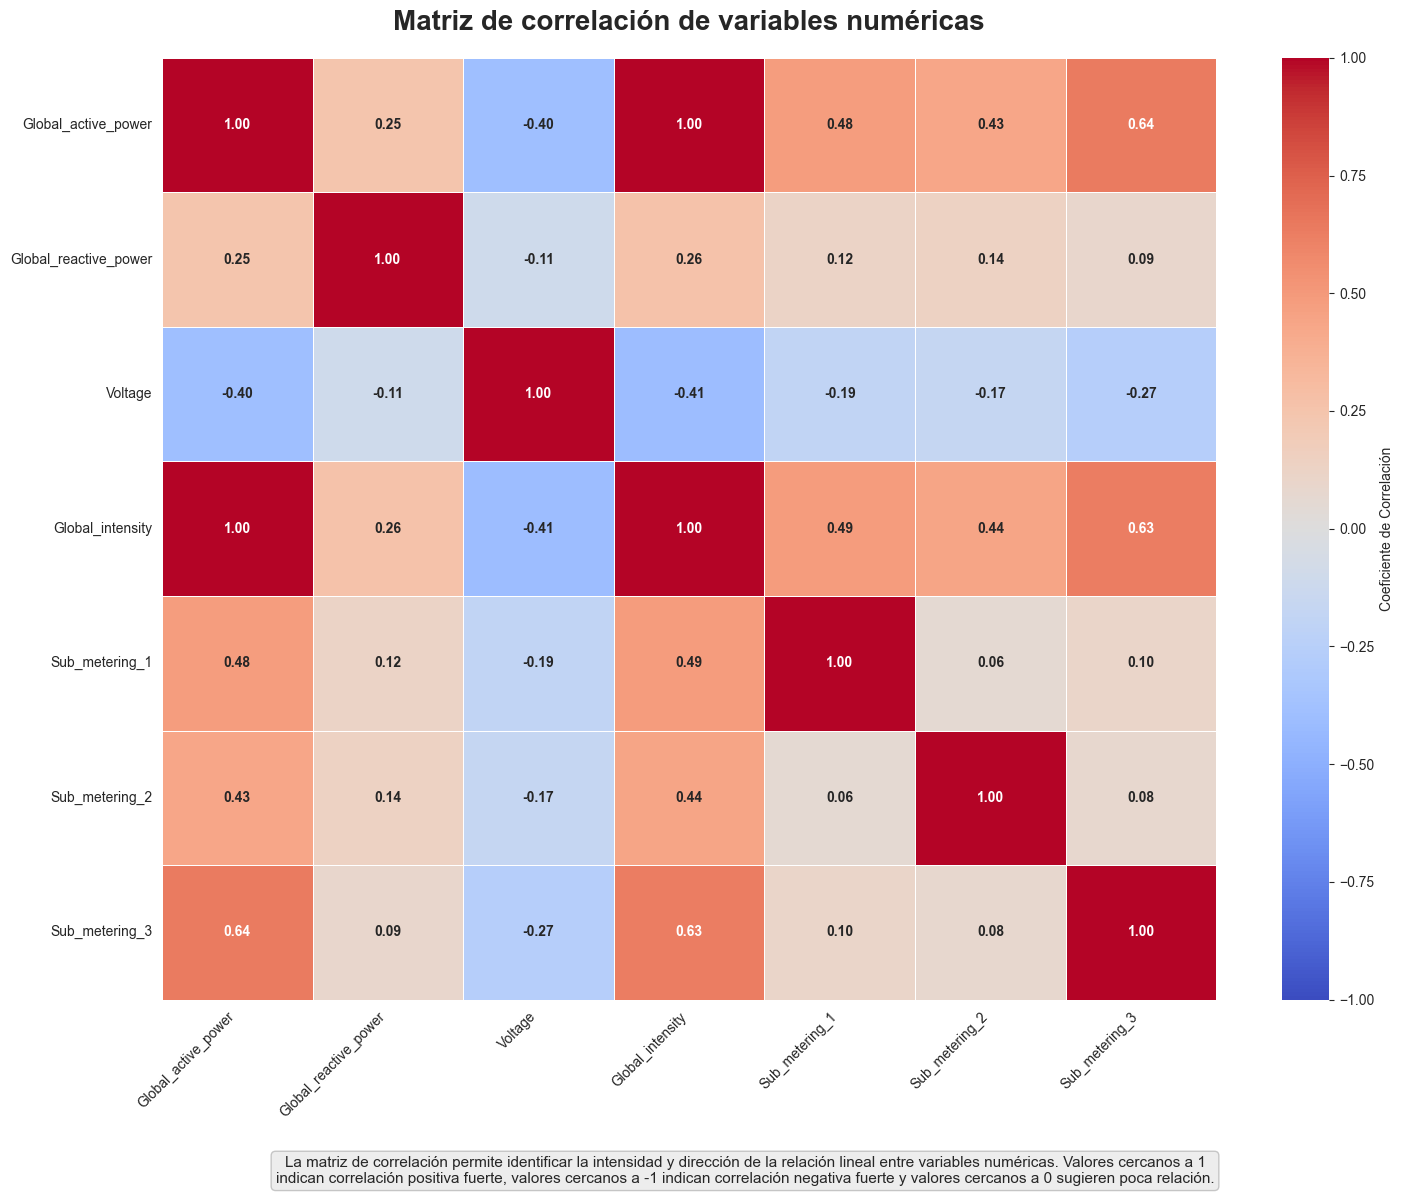

In [21]:
# Variables numéricas que interesan para la correlación
col_num_df4_corr = df4_clean_imputado.select_dtypes(include=[np.number]).columns
# Ahora llamo a mi funcion de correlación
matriz_corr(df4_clean_imputado, col_num_df4_corr)

### Resumen del EDA para Consumo de Energía Doméstica

#### Observaciones generales: Partí con un dataset gigante de 2075259 registros y 9 columnas. Después de la limpieza, me quedé con la misma cantidad de registros pero con una columna DateTime nueva y las Date y Time originales eliminadas.
* Se Identificó que varias columnas numéricas estaban como object y Sub_metering_3 tenía 25979 valores nulos. Se convirtió correctamente las columnas a float y utilicé la interpolación lineal basada en tiempo para rellenar los nulos, lo que para mí fue una excelente estrategia para mantener la integridad temporal de los datos. Así me aseguré de que no queden huecos sin información.
* No se detectaron filas duplicadas en este dataset, lo que simplifica la limpieza inicial.
* La creación de la columna DateTime unificada es crucial, ya que me permite analizar los datos como una serie temporal continua, abriendo la puerta a análisis de tendencias y patrones estacionales.

#### Análisis de distribuciones:

* **Global Active/Reactive Power y Global Intensity:** Los histogramas muestran que el consumo activo y la intensidad tienen distribuciones concentradas en valores bajos, con una cola que se extiende a valores más altos. Lo que intuyo sucede porque la mayoría del tiempo el consumo es bajo, pero hay saltos cuando se usan electrodomésticos grandes. Global_reactive_power también sigue un patrón similar, pero con valores generalmente más bajos.
* **Voltage:** La distribución del Voltage es más simétrica y concentrada alrededor de un valor central, lo que indica una relativa estabilidad en el suministro eléctrico, con pequeñas variaciones.
*   **Sub-metering (1, 2, 3):** Los sub-medidores muestran distribuciones con una alta concentración en cero o valores muy bajos, lo que sugiere que esos sistemas de consumo no están siempre en uso o no siempre consumen. Esto es esperable en un hogar, donde los aparatos se usan intermitentemente.

#### Outliers: Los boxplots confirman la presencia de muchos outliers en todas las variables de consumo. Estos outliers no son necesariamente errores, sino que representan momentos de consumo excepcionalmente alto, como cuando se encienden varios electrodomésticos a la vez, o flujos de alta de demanda. En el caso del Voltage, los outliers serían momentos de sobre o sub-tensión. En un contexto de series de tiempo como este, los outliers son a menudo eventos de interés. Podrían ser períodos de máxima demanda, fallas en equipos, o simplemente el uso normal pero intensivo de ciertos aparatos. Su análisis puede revelar patrones de uso o identificar anomalías.

#### Análisis de la matriz de correlación:

* Se observa una correlación positiva extremadamente alta entre Global_active_power, Global_intensity y Global_reactive_power. Esto es lógico, ya que todos están relacionados con el consumo total de energía y la forma en que se distribuye.
* Los Sub_metering_1, Sub_metering_2 y Sub_metering_3 muestran correlaciones positivas con las variables globales, aunque de magnitud variable. Esto es natural, ya que contribuyen al consumo total.
* Voltage tiende a tener correlaciones más bajas con las otras variables de consumo, lo cual es esperable ya que es una medida de la calidad de la energía entregada, no del consumo en sí mismo, aunque puede influir.

### El problema más evidente es predecir el consumo de energía en el futuro (por ejemplo, la próxima hora, el próximo día). Esto es fundamental para la gestión energética.
* Identificar automáticamente períodos de consumo anormalmente alto o bajo que puedan indicar fallas, usos ineficientes o incluso eventos inusuales en el hogar.
* Segmentar los días o las semanas según los patrones de consumo para entender los hábitos de los residentes, por ejemplo, patrón de día laboral vs. fin de semana, patrones nocturnos, días festivos entre otros.